In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
%pwd

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import sys

print(sys.version)

3.14.3 (main, Mar  3 2026, 15:00:44) [MSC v.1944 64 bit (AMD64)]


In [4]:
import os, re, sys, traceback, csv, random

import numpy as np
import pandas as pd
import sentencepiece as spm
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [5]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

'export' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
import generator_core as core
from aspect_teal import Teal
import aspect_teal
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V
from aspect_tetra import SolutionEvaluator

In [7]:
from dl_trainer import Trainer

In [8]:
batch_count = 103
genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
print(genres)
print(batch_count)

{'pop', 'country', 'rb', 'misc', 'rap', 'rock'}
103


In [9]:
total_subset_size = 100000
total_group_size = total_subset_size // len(genres) + 1
max_songs_per_artist = 50

In [10]:
ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
display(ds_subset.head())

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [11]:
teal = Teal(ds_subset)

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Teal._get_custom_tokens.cached
Loaded Cache for Teal._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\Teal.lyrics_sp.model
Loaded Cache for Teal._prepare_embedder.cached
Loaded Cache for Teal._prepare_language_model.cached


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

cuda


In [13]:
word2vec = teal.embedder
word2vec

Word2Vec_SkipGram(
  (embeddings): Embedding(16000, 512)
  (linear): Linear(in_features=512, out_features=16000, bias=True)
)

In [14]:
word2vec.trainer.checkpoint_frequency_batch = 10
word2vec.trainer.device = 'cuda'
word2vec.trainer.learning_rate(0.001)

In [15]:
# word2vec.trainer.train()

In [16]:
try:
    flight = 'Teal._prepare_embedder.cached'
    for file in ['bone', 'pkl']:
        file = os.path.join('temp', f'{flight}.{file}')
        if os.path.exists(file): os.remove(file)
    core.key_cached('cached', lambda: word2vec, group='Teal._prepare_embedder')
    print("Done")
except:
    traceback.print_exc()

Done


In [15]:
try:
    train_language_model = True

    print(teal.language_model)
    print(teal.get_language_model_parameter_count())
except:
    traceback.print_exc()

TransformerModel(
  (embed): Embedding(16000, 512, padding_idx=0)
  (pe): SinusoidalPE()
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (dropout): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): GQAAttention(
        (q_proj): Linear(in_features=512, out_features=512, bias=True)
        (k_proj): Linear(in_features=512, out_features=256, bias=True)
        (v_proj): Linear(in_features=512, out_features=256, bias=True)
        (out_proj): Linear(in_features=512, out_features=512, bias=True)
      )
      (ffn): GELUFFN(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
    )
  )
  (norm): LayerNorm()
  (head): Linear(in_features=512, out_features=16000, bias=True)
)
11575936


In [16]:
torch.cuda.empty_cache()

In [17]:
trainer = teal.language_model.trainer

In [20]:
trainer.learning_rate(0.00005)
trainer.epochs = 1

In [21]:
trainer.train()
# CPU Time: 34 sit

Epoch:  0/ 1    Train Loss: 2.46    TTS: 1.43    ETA: 7164.25
Epoch:  0/ 1    Train Loss: 2.18    TTS: 2.21    ETA: 7379.73
Epoch:  0/ 1    Train Loss: 2.36    TTS: 3.21    ETA: 6408.98
Epoch:  0/ 1    Train Loss: 1.88    TTS: 4.23    ETA: 6035.26
Epoch:  0/ 1    Train Loss: 2.32    TTS: 5.18    ETA: 5750.52
Epoch:  0/ 1    Train Loss: 2.12    TTS: 6.32    ETA: 5741.62
Epoch:  0/ 1    Train Loss: 2.21    TTS: 7.31    ETA: 5612.89
Epoch:  0/ 1    Train Loss: 2.30    TTS: 8.23    ETA: 5479.43
Epoch:  0/ 1    Train Loss: 2.34    TTS: 9.20    ETA: 5400.85
Epoch:  0/ 1    Train Loss: 2.87    TTS: 10.25    ETA: 5386.61
Epoch:  0/ 1    Train Loss: 2.78    TTS: 11.20    ETA: 5322.09
Epoch:  0/ 1    Train Loss: 2.25    TTS: 12.21    ETA: 5295.65
Epoch:  0/ 1    Train Loss: 2.87    TTS: 13.35    ETA: 5123.29
Epoch:  0/ 1    Train Loss: 2.36    TTS: 14.18    ETA: 5050.67
Epoch:  0/ 1    Train Loss: 2.12    TTS: 15.37    ETA: 5107.36


KeyboardInterrupt: 

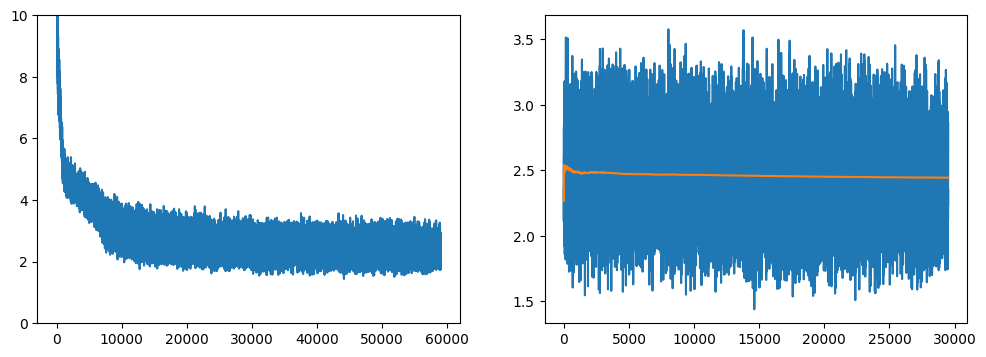

In [21]:
def running_average(nums):
    nums = np.asarray(nums, dtype=float)
    kernel = np.ones(len(nums))
    cumsum = np.convolve(nums, kernel, mode='full')[:len(nums)]
    counts = np.arange(1, len(nums) + 1)
    return cumsum / counts


loss = trainer.loss
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(loss['train.batch'])
axs[0].set_ylim(0, 10)
axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
axs[1].plot(running_average(loss['train.batch'][int(0.5 * len(loss['train.batch'])):]))
plt.show()

In [42]:
try:
    flight = 'Teal._prepare_language_model.cached'
    for file in ['bone', 'pkl']:
        file = os.path.join('temp', f'{flight}.{file}')
        if os.path.exists(file): os.remove(file)
    core.key_cached('cached', lambda: teal.language_model, group='Teal._prepare_language_model')
    print("Saved")
except:
    traceback.print_exc()

Creating Cache for Teal._prepare_language_model.cached
Saved


In [23]:
for key in teal.language_model.trainer.timer.timers:
    print(key, trainer.timer.timers[key].average)

train 0.0
_train_step 0.0
train_dataloader 0.014799528626877743
batch 0.28455686167855393


In [25]:
try:
    print(teal.inference('rock',
                         ['black', 'enter', 'spell', 'priests', 'dragon'],
                         starting_words='<VERSE> i feel the fire',
                         max_len=400,
                         temperature=0.9,
                         top_k=50,
                         top_p=0.9, penalty=1.2).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

<SONG_START> <VERSE> i feel the fire in my lungs and blooded out from his eyes
where we travel here on earth is where this road will be now , where will you belong with us ?
i'll never go back to where there is no light has ever been as good as time was long ago
then the serpent died over me and they had not seen before
so i look down to see it coming again and again !
i saw a story i hope that i hear those voice of your skin and stare at me
she left my eye for him and he couldn't give me a reason
i walked away without a word she turned around
but also you must leave all the rules . he said " let's do it one more chance , if you failed me until i heard a promise
you made me wish and i could take her home "
because i told her that i wouldn't say bye
<CHORUS>
i am falling into the sun i wanna be born free ( born free )
i am falling into the sun i wanna be born free
[ instrumental break ]
<VERSE>
then the serpent died over me and they had not seen before
so i look down to see it coming ag

In [14]:


g, c, l = teal.get_genre(56), " ".join(teal.get_context_words(56)), teal.get_lyrics(56)
logits = teal.get_logits([(g, c, l)])
print(logits.shape)



torch.Size([1, 391, 16000])


In [20]:
from generator_core import pad_lists

In [12]:
try:
    _songs = teal.bulk_inference(
                            genres=['rock', 'pop', 'misc', 'country'],
                            context_words=['black enter spell priests dragon', 'black enter spell', 'priests dragon', 'abcdefghi'],
                            max_len=500,
                            temperature=1.0,
                            top_k=20,
                            )
    for i, s in enumerate(_songs):
        print("SONG ", i + 1)
        print(s)
        print()
except:
    traceback.print_exc()

SONG  1
genre rock black enter spell priests dragon a woman with no name to see you as much as it is
so she can take your hand , her body is so cold
the moon is falling in love with you now
and it makes me smile for your life , but now you've found
it takes me far away from here
so you may think i am sure
how to make them feel
you're looking back to the dark
and let her tell the stars
you see the stars above and through her eyes
leading down the hall and the world is burning
and when they look at you
we'll turn into dust and tear away
so you may think i am sure
how to make them feel
you're looking back to the dark
and let her tell the light
you see the sun above and through her eyes
leading down the hall and the world is burning
and when they look at you
you gotta see the stars above and through her eyes
leading down the hall and the world is burning
and when they look at you
you gotta see the stars above and through her eyes 

SONG  2
genre pop black enter spell ⁇  ⁇  ⁇ 0 : 30
this on

In [13]:
try:
    # teal.language_model.pe.pe = teal.language_model.pe.pe.to('cuda')
    print(teal.language_model)
except:
    traceback.print_exc()

TransformerModel(
  (embed): Embedding(16000, 512, padding_idx=0)
  (pe): SinusoidalPE()
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (dropout): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): GQAAttention(
        (q_proj): Linear(in_features=512, out_features=512, bias=True)
        (k_proj): Linear(in_features=512, out_features=256, bias=True)
        (v_proj): Linear(in_features=512, out_features=256, bias=True)
        (out_proj): Linear(in_features=512, out_features=512, bias=True)
      )
      (ffn): GELUFFN(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
        )
      )
    )
  )
  (norm): LayerNorm()
  (head): Linear(in_features=512, out_features=16000, bias=True)
)


In [13]:
try:
    evaluator = SolutionEvaluator(teal)
except:
    traceback.print_exc()

In [14]:
try:
    bertscore = evaluator.compute_bertscore()
    print(bertscore)
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6974.47it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'precision': np.float64(0.7284026145935059), 'recall': np.float64(0.6318249106407166), 'f1': np.float64(0.6766852140426636)}


In [16]:
try:
    mauve = evaluator.compute_mauve()
    print(mauve)
except:
    traceback.print_exc()

Featurizing q: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]

0.0040720962619612555


In [30]:
try:
    perplexity = evaluator.compute_perplexity(collate=evaluator.default_zip_collate)
    print(perplexity)
except:
    traceback.print_exc()

10.614079809188842


In [32]:
try:
    self_bleu = evaluator.compute_self_bleu()
    print(self_bleu)
except:
    traceback.print_exc()

0.005010214286330875


In [33]:
try:
    print("Bert Score:")
    print(f" * Precision : {bertscore['precision']:.3f}")
    print(f" * Recall    : {bertscore['recall']:.3f}")
    print(f" * F1 Measure: {bertscore['f1']:.3f}")
    print(f"Mauve Score  : {mauve:.3f}")
    print(f"Perplexity   : {perplexity:.3f}")
    print(f"Self BLUE    : {self_bleu:.3f}")
except:
    traceback.print_exc()

Bert Score:
 * Precision : 0.728
 * Recall    : 0.632
 * F1 Measure: 0.677
Mauve Score  : 0.004
Perplexity   : 10.614
Self BLUE    : 0.005
